# 🧠 Görüntü İşleme — İleri Seviye

> **Ön koşul:** Temel notebook tamamlanmış olmalı (piksel, filtreler, kenar tespiti, KNN).  
> Bu notebook bir üst katmana çıkar: **derin öğrenme fikirleri, CNN sıfırdan, SVM, veri artırma, t-SNE görselleştirme, gerçek transfer learning pipeline.**

---

## 📚 Bu Notebook'ta Ne Öğreneceksiniz?

| # | Bölüm | Zorluk |
|---|-------|--------|
| 13 | Veri Artırma (Data Augmentation) | ⭐⭐ |
| 14 | PCA ile Boyut İndirgeme + Görselleştirme | ⭐⭐ |
| 15 | t-SNE ile Özellik Uzayı Keşfi | ⭐⭐⭐ |
| 16 | Konvolüsyon Katmanı — Sıfırdan NumPy | ⭐⭐⭐ |
| 17 | Aktivasyon Fonksiyonları ve Özellik Haritaları | ⭐⭐⭐ |
| 18 | Tam Bağlı Sinir Ağı (MLP) ile Sınıflandırma | ⭐⭐⭐ |
| 19 | SVM vs MLP vs KNN — Kapsamlı Karşılaştırma | ⭐⭐⭐ |
| 20 | Grad-CAM Benzeri Isı Haritası (Saliency Map) | ⭐⭐⭐⭐ |
| 21 | Gerçek CNN Pipeline — Sıfırdan İleri Yayılım | ⭐⭐⭐⭐ |

> **Veri Seti:** sklearn digits (1797 × 8×8 el yazısı rakam) + scipy gerçek fotoğrafları


## ⚙️ Kurulum

In [1]:

# ── Tüm kütüphaneleri içe aktar ───────────────────────────────────────────────
import numpy as np                          # Matris işlemleri — CNN'in kalbi
import matplotlib.pyplot as plt             # Görselleştirme
import matplotlib.colors as mcolors        # Renk haritası yardımcıları
from matplotlib.gridspec import GridSpec    # Karmaşık subplot düzeni

import cv2                                  # OpenCV — görüntü ön işleme
from scipy import datasets as scd           # Gerçek test görüntüleri

from sklearn.datasets import load_digits    # El yazısı rakam veri seti
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA       # Temel Bileşen Analizi
from sklearn.manifold import TSNE           # t-dağılımlı Stokastik Komşu Yerleştirme
from sklearn.svm import SVC                 # Destek Vektör Makinesi
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier   # Çok Katmanlı Algılayıcı (sinir ağı)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)
from sklearn.pipeline import Pipeline       # Ön işleme + model zinciri

import warnings
warnings.filterwarnings('ignore')

# ── Veri setlerini yükle ──────────────────────────────────────────────────────
digits      = load_digits()
X_digits    = digits.images               # (1797, 8, 8)  — 2D görüntüler
y_digits    = digits.target               # (1797,)        — 0-9 etiketler
X_flat      = digits.data                 # (1797, 64)     — düzleştirilmiş
img_color   = scd.face()                  # (768, 1024, 3) — gerçek fotoğraf
img_gray_raw = scd.ascent()              # (512, 512)     — gri fotoğraf

# Eğitim/test bölmesi — tüm bölümlerde kullanılacak
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_digits, test_size=0.25, random_state=42, stratify=y_digits
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Eğitimde fit+transform
X_test_sc  = scaler.transform(X_test)        # Testte sadece transform

plt.rcParams['figure.dpi'] = 100
print("✅ Kurulum tamamlandı!")
print(f"   Eğitim: {X_train.shape[0]} örnek  |  Test: {X_test.shape[0]} örnek")
print(f"   Özellik boyutu: {X_flat.shape[1]} (8×8 piksel)")


✅ Kurulum tamamlandı!
   Eğitim: 1347 örnek  |  Test: 450 örnek
   Özellik boyutu: 64 (8×8 piksel)


## 🔀 Bölüm 13 — Veri Artırma (Data Augmentation)

**Problem:** Gerçek projelerde etiketli veri az olur. Modeli overfit'ten korumak için
mevcut görüntüleri **dönüştürerek** yapay yeni örnekler üretilir.

**Neden işe yarar?** Model aynı nesnenin farklı açı/parlaklık/gürültü versiyonlarını görünce
gerçek dünya varyasyonlarını öğrenir.

```
Orijinal → Döndür → Kaydır → Ölçekle → Gürültü ekle → Ayna → Parlaklık değiştir
```


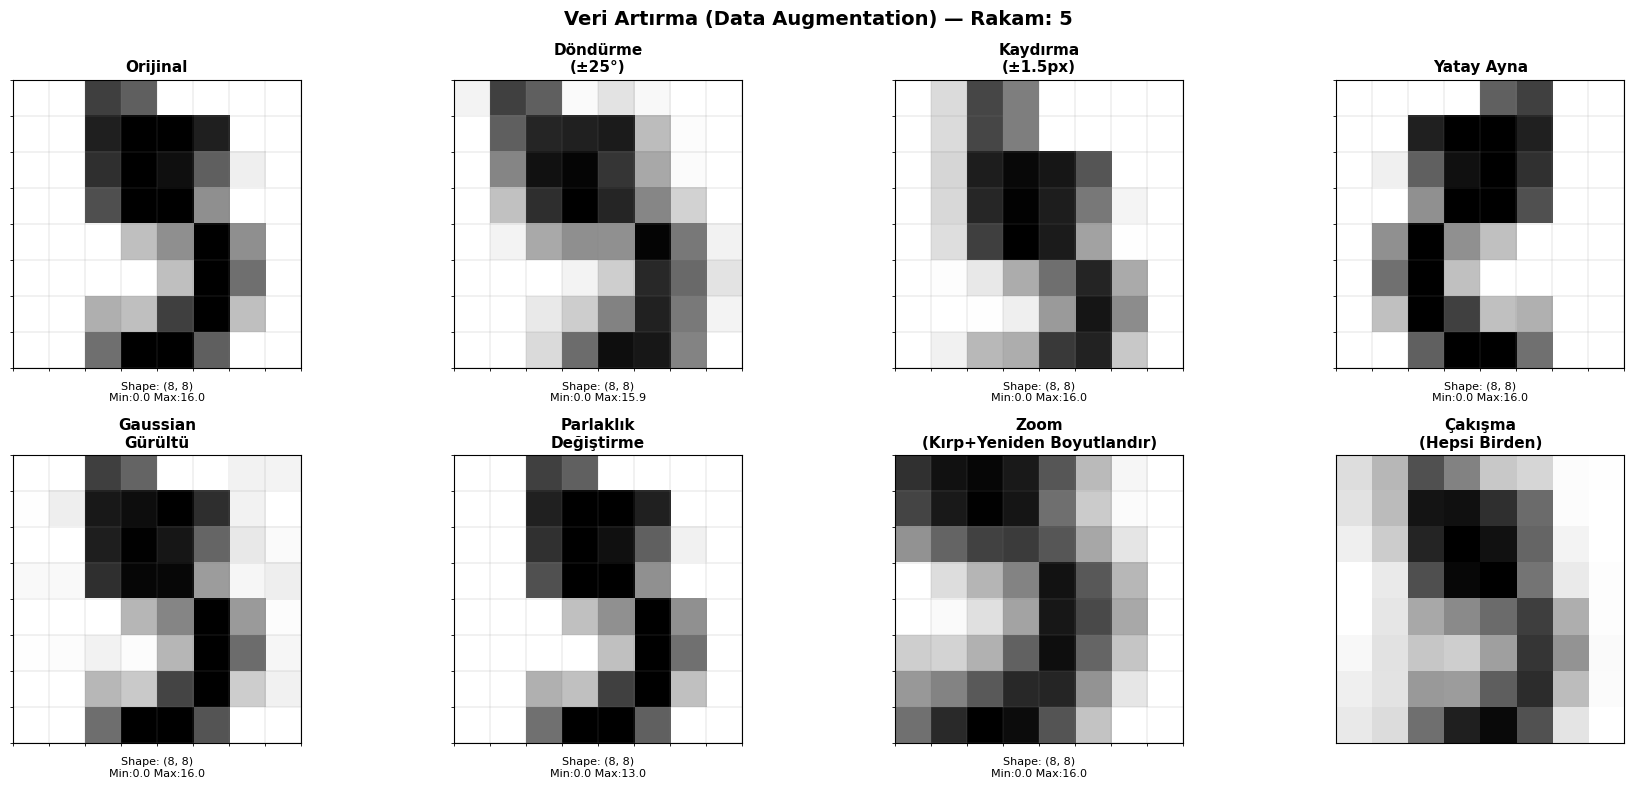

In [2]:

def augment_image(img_2d, seed=None):
    # #     Tek bir 8x8 görüntüye rastgele augmentation uygula.
    #     Dönüş: sözlük — her dönüşümün sonucu ayrı ayrı
    #
    rng = np.random.default_rng(seed)          # Tekrar üretilebilir rastgelelik
    
    # PIL için uint8'e çevir (0-16 aralığı → 0-255)
    img_uint8 = ((img_2d / 16.0) * 255).astype(np.uint8)   # Normalize et → 8-bit

    results = {}
    results['original'] = img_2d.copy()        # Orijinali sakla

    # ── 1. Döndürme (Rotation) ──────────────────────────────────────────────
    angle = rng.uniform(-25, 25)               # -25° ile +25° arası rastgele açı
    h, w  = img_uint8.shape
    M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)   # Dönme matrisi
    rotated = cv2.warpAffine(img_uint8, M, (w, h),
                              borderMode=cv2.BORDER_REPLICATE)   # Kenar boşluğunu doldur
    results['rotation'] = rotated.astype(float) / 255 * 16      # Geri normalize et

    # ── 2. Kaydırma (Translation) ──────────────────────────────────────────
    tx = rng.uniform(-1.5, 1.5)               # X yönünde ±1.5 piksel
    ty = rng.uniform(-1.5, 1.5)               # Y yönünde ±1.5 piksel
    M_trans = np.float32([[1, 0, tx],         # Kaydırma matrisi
                           [0, 1, ty]])
    shifted = cv2.warpAffine(img_uint8, M_trans, (w, h),
                              borderMode=cv2.BORDER_REPLICATE)
    results['translation'] = shifted.astype(float) / 255 * 16

    # ── 3. Yatay Ayna (Horizontal Flip) ────────────────────────────────────
    # Not: Rakamlar için tehlikeli (6 ↔ 9, vb.) ama pipeline'ı göstermek için
    flipped = np.fliplr(img_uint8)             # Sütunları tersine çevir
    results['flip'] = flipped.astype(float) / 255 * 16

    # ── 4. Gaussian Gürültü ─────────────────────────────────────────────────
    sigma  = rng.uniform(5, 20)               # Rastgele gürültü şiddeti
    noise  = rng.normal(0, sigma, img_uint8.shape).astype(np.int16)
    noisy  = np.clip(img_uint8.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    results['noise'] = noisy.astype(float) / 255 * 16

    # ── 5. Parlaklık Değiştirme (Brightness) ───────────────────────────────
    factor = rng.uniform(0.6, 1.6)            # 0.6× (karartma) ile 1.6× (aydınlatma)
    bright = np.clip(img_uint8.astype(float) * factor, 0, 255).astype(np.uint8)
    results['brightness'] = bright.astype(float) / 255 * 16

    # ── 6. Zoom (Kırp + Yeniden Boyutlandır) ───────────────────────────────
    zoom   = rng.uniform(0.7, 0.95)           # Görüntünün %70-95'ini al
    crop_h = int(h * zoom)
    crop_w = int(w * zoom)
    y0     = rng.integers(0, h - crop_h + 1)  # Rastgele kırpma başlangıcı
    x0     = rng.integers(0, w - crop_w + 1)
    cropped  = img_uint8[y0:y0+crop_h, x0:x0+crop_w]
    zoomed   = cv2.resize(cropped, (w, h))    # Orijinal boyuta geri döndür
    results['zoom'] = zoomed.astype(float) / 255 * 16

    return results

# ── İlk birkaç örnek üzerinde augmentation göster ────────────────────────────
sample_img = X_digits[5]                      # 5 numaralı görüntüyü al (rakam=1)
aug_results = augment_image(sample_img, seed=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

titles = ['Orijinal', 'Döndürme\n(±25°)', 'Kaydırma\n(±1.5px)',
          'Yatay Ayna', 'Gaussian\nGürültü', 'Parlaklık\nDeğiştirme',
          'Zoom\n(Kırp+Yeniden Boyutlandır)', 'Çakışma\n(Hepsi Birden)']

for i, (key, img) in enumerate(aug_results.items()):
    axes[i].imshow(img, cmap='gray_r', interpolation='nearest')  # Piksel sınırları görünsün
    axes[i].set_title(titles[i], fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f"Shape: {img.shape}\nMin:{img.min():.1f} Max:{img.max():.1f}", fontsize=8)
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    # Piksel ızgarasını göster
    axes[i].set_xticks(np.arange(-0.5, 8, 1), minor=True)
    axes[i].set_yticks(np.arange(-0.5, 8, 1), minor=True)
    axes[i].grid(which='minor', color='gray', linewidth=0.3, alpha=0.5)

# Son panel: tüm augmentasyonların yığınlanmış görüntüsü
combined = np.mean([v for v in aug_results.values()], axis=0)  # Ortalama görüntü
axes[7].imshow(combined, cmap='gray_r', interpolation='nearest')
axes[7].set_title(titles[7], fontsize=11, fontweight='bold')
axes[7].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle(f"Veri Artırma (Data Augmentation) — Rakam: {y_digits[5]}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:

# ── Augmentation ile veri setini büyüt ve sınıflandırma etkisini göster ───────

def build_augmented_dataset(X_img, y, n_aug=3, seed=0):
    # #     Her görüntüye n_aug kez augmentation uygulayarak veri setini büyüt.
    #     Döner: (X_aug, y_aug) — orijinaller dahil
    #
    X_list, y_list = [X_img.flatten().reshape(len(X_img), -1)], [y]  # Orijinaller
    rng = np.random.default_rng(seed)
    
    for aug_round in range(n_aug):
        X_new = []
        for i, img in enumerate(X_img):
            s = rng.integers(0, 10000)
            aug = augment_image(img, seed=int(s))
            # Her turda farklı bir augmentation tipi seç
            key = list(aug.keys())[1 + (aug_round % 6)]  # 'original' hariç
            X_new.append(aug[key].flatten())              # 8×8 → 64 özellik
        X_list.append(np.array(X_new))
        y_list.append(y)
    
    return np.vstack(X_list), np.concatenate(y_list)

# Sadece eğitim verisi üzerinde augmentation uygula (test'e dokunma!)
print("Augmentation uygulanıyor...")
X_train_imgs = X_digits[np.isin(np.arange(len(y_digits)), 
               np.where(np.isin(y_digits, np.unique(y_train)))[0])]

# Daha pratik: train index'leri doğrudan hesapla
train_idx, test_idx, _, _ = train_test_split(
    np.arange(len(y_digits)), y_digits, test_size=0.25, random_state=42, stratify=y_digits
)
X_tr_imgs = X_digits[train_idx]
y_tr      = y_digits[train_idx]
X_te_flat = X_digits[test_idx].reshape(len(test_idx), -1)
y_te      = y_digits[test_idx]

# Augmented dataset oluştur
X_aug, y_aug = build_augmented_dataset(X_tr_imgs, y_tr, n_aug=3)
print(f"Orijinal eğitim seti  : {len(y_tr)} örnek")
print(f"Augmented eğitim seti : {len(y_aug)} örnek  (4× büyüdü)")

# Her iki veriyle MLP eğit ve karşılaştır
sc = StandardScaler()
X_tr_sc  = sc.fit_transform(X_flat[train_idx])     # Orijinal
X_aug_sc = sc.fit_transform(X_aug)                  # Augmented
X_te_sc  = sc.transform(X_te_flat)

mlp_orig = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42)
mlp_aug  = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42)

mlp_orig.fit(X_tr_sc,  y_tr)
mlp_aug.fit(X_aug_sc, y_aug)

acc_orig = accuracy_score(y_te, mlp_orig.predict(X_te_sc))
acc_aug  = accuracy_score(y_te, mlp_aug.predict(X_te_sc))

print(f"\nTest Doğruluğu — Orijinal veri : {acc_orig*100:.2f}%")
print(f"Test Doğruluğu — Augmented veri: {acc_aug*100:.2f}%")
print(f"Augmentation kazancı            : {(acc_aug-acc_orig)*100:+.2f} puan")


Augmentation uygulanıyor...


Orijinal eğitim seti  : 1347 örnek
Augmented eğitim seti : 5388 örnek  (4× büyüdü)



Test Doğruluğu — Orijinal veri : 97.56%
Test Doğruluğu — Augmented veri: 98.22%
Augmentation kazancı            : +0.67 puan


## 📉 Bölüm 14 — PCA ile Boyut İndirgeme

**Problem:** 64 özellik → görselleştirme imkânsız.  
**PCA (Principal Component Analysis):** Veriyi en fazla varyansı koruyan eksenlere yansıtır.

**Matematiksel özü:** Kovaryans matrisinin öz vektörleri = yeni eksenler.  
Her öz vektör bir **"eigenface"** (öz görüntü) gibi düşünülebilir.

```
64 boyut  →PCA→  2-3 boyut   (görselleştirme için)
64 boyut  →PCA→  30-40 boyut (sınıflandırma için, bilgi kaybı az)
```


%90 varyans için gerekli bileşen: 21
%95 varyans için gerekli bileşen: 29
%99 varyans için gerekli bileşen: 41
Orijinal boyut: 64  →  Sıkıştırma oranı (%90): 3.0×


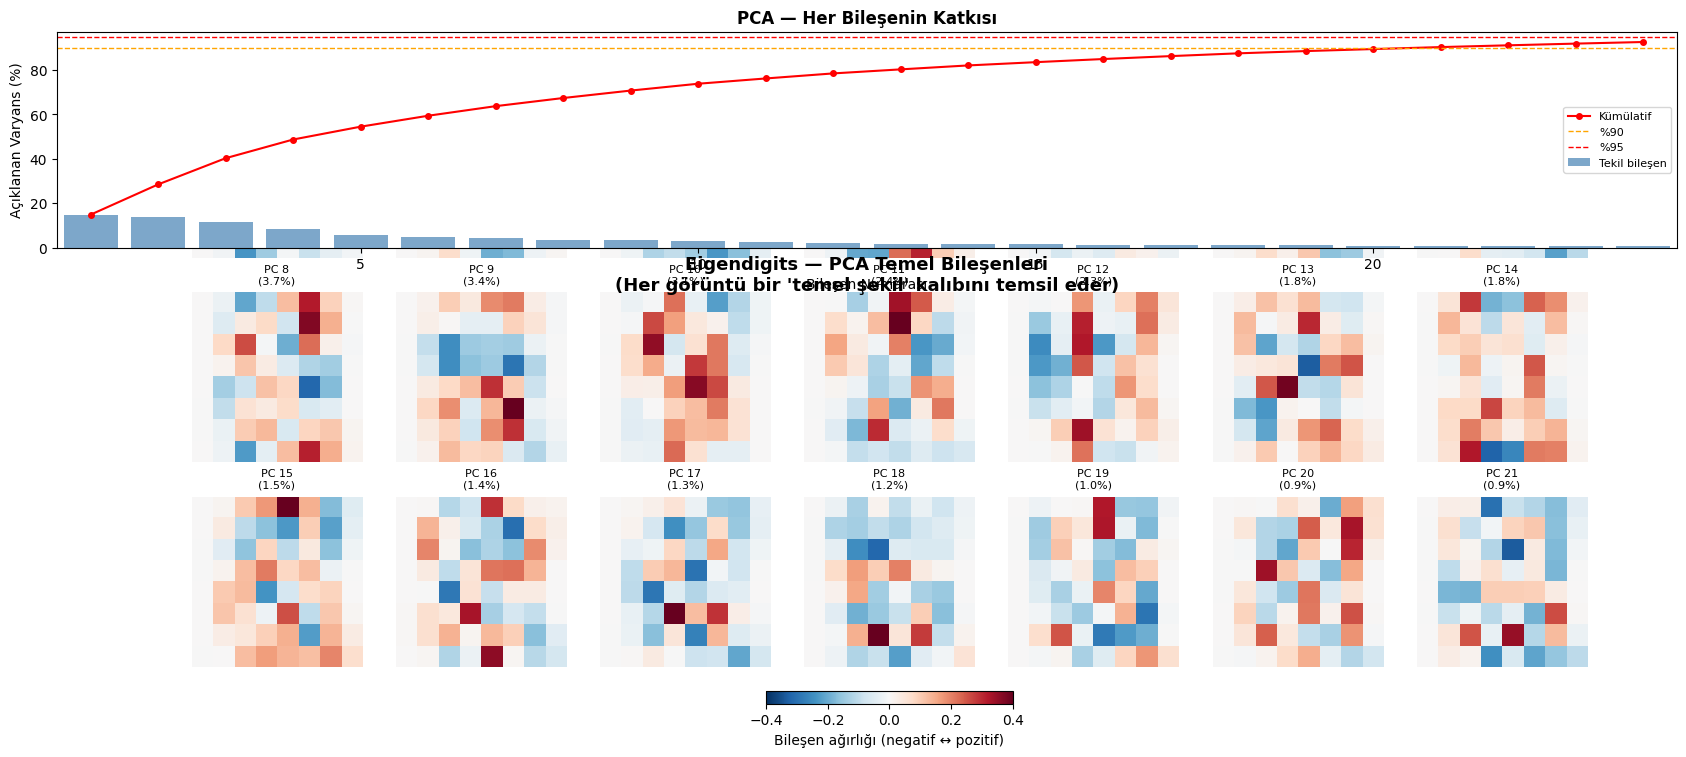

In [4]:

# ── PCA ile Boyut İndirgeme ───────────────────────────────────────────────────
pca_full = PCA()                               # Tüm bileşenleri hesapla (fit)
pca_full.fit(X_flat)                           # 64 bileşenin hepsini öğren

# Kümülatif açıklanan varyans — kaç bileşen yeterli?
cumvar = np.cumsum(pca_full.explained_variance_ratio_)   # Her bileşenin katkısını topla
n90  = np.searchsorted(cumvar, 0.90) + 1       # %90 için gereken bileşen sayısı
n95  = np.searchsorted(cumvar, 0.95) + 1       # %95 için
n99  = np.searchsorted(cumvar, 0.99) + 1       # %99 için

print(f"%90 varyans için gerekli bileşen: {n90}")
print(f"%95 varyans için gerekli bileşen: {n95}")
print(f"%99 varyans için gerekli bileşen: {n99}")
print(f"Orijinal boyut: 64  →  Sıkıştırma oranı (%90): {64/n90:.1f}×")

# ── Eigendigits (PCA bileşenlerini görselleştir) ──────────────────────────────
# Her öz bileşen, veri setindeki bir 'temel şekil'i temsil eder
fig, axes = plt.subplots(3, 7, figsize=(18, 8))

# İlk satır: varyans grafiği
ax_var = fig.add_axes([0.05, 0.68, 0.90, 0.27])  # [left, bottom, width, height]
ax_var.bar(range(1, 25), pca_full.explained_variance_ratio_[:24]*100,
           color='steelblue', alpha=0.7, label='Tekil bileşen')
ax_var.plot(range(1, 25), cumvar[:24]*100,
            'ro-', markersize=4, linewidth=1.5, label='Kümülatif')
ax_var.axhline(y=90, color='orange', linestyle='--', linewidth=1, label='%90')
ax_var.axhline(y=95, color='red',    linestyle='--', linewidth=1, label='%95')
ax_var.set_xlabel("Bileşen Numarası")
ax_var.set_ylabel("Açıklanan Varyans (%)")
ax_var.set_title("PCA — Her Bileşenin Katkısı", fontweight='bold')
ax_var.legend(loc='right', fontsize=8)
ax_var.set_xlim(0.5, 24.5)

# Eigendigit görüntüleri (her bileşen bir 8×8 görüntüye reshape edilebilir)
for i, ax in enumerate(axes.flatten()):
    if i < 21:
        eigenimg = pca_full.components_[i].reshape(8, 8)   # 64 → 8×8
        im = ax.imshow(eigenimg, cmap='RdBu_r',             # Kırmızı-Mavi: pozitif/negatif
                       vmin=-0.4, vmax=0.4)
        ax.set_title(f"PC {i+1}\n({pca_full.explained_variance_ratio_[i]*100:.1f}%)",
                     fontsize=8)
        ax.axis('off')

# Colorbar
fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.02, pad=0.04,
             label='Bileşen ağırlığı (negatif ↔ pozitif)')

plt.suptitle("Eigendigits — PCA Temel Bileşenleri\n(Her görüntü bir 'temel şekil' kalıbını temsil eder)",
             fontsize=13, fontweight='bold', y=0.67)
plt.show()


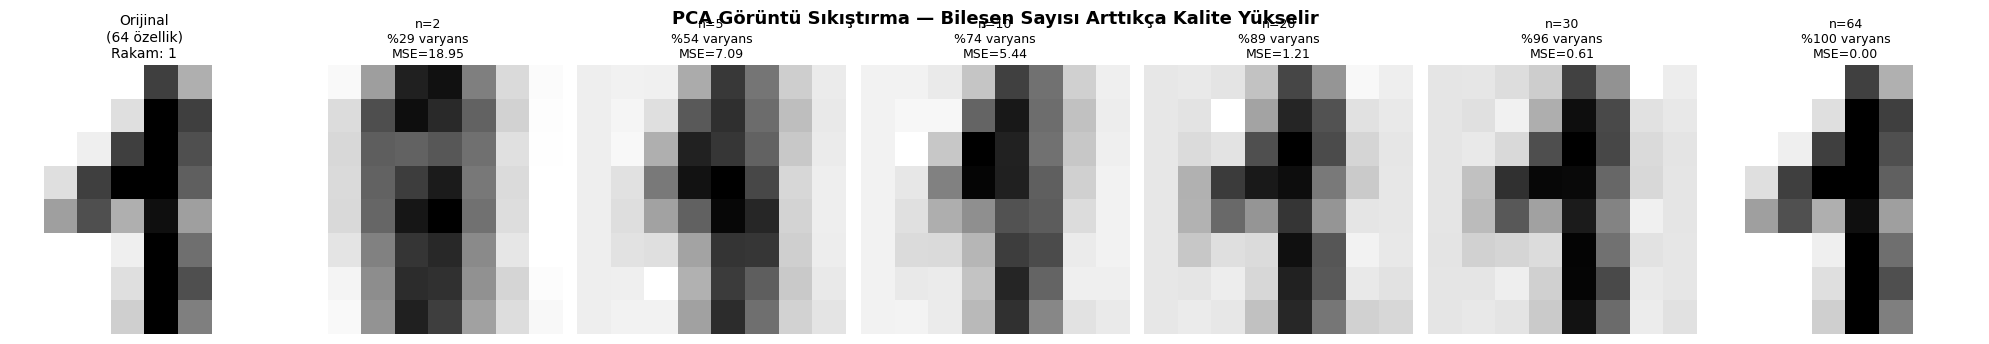

In [5]:

# ── PCA ile Görüntü Sıkıştırma ve Yeniden Yapılandırma ───────────────────────
# n bileşenle sıkıştır → orijinal boyuta geri döndür ve kaliteyi karşılaştır

n_components_list = [2, 5, 10, 20, 30, 64]   # Kaç bileşen kullanılacak?
sample_idx = 42                               # Gösterilecek örnek indeksi
original   = X_flat[sample_idx]              # Orijinal düzleştirilmiş görüntü

fig, axes = plt.subplots(1, len(n_components_list)+1, figsize=(20, 3.5))

axes[0].imshow(original.reshape(8,8), cmap='gray_r', interpolation='nearest')
axes[0].set_title(f"Orijinal\n(64 özellik)\nRakam: {y_digits[sample_idx]}", fontsize=10)
axes[0].axis('off')

for j, n in enumerate(n_components_list):
    pca_n = PCA(n_components=n)                    # n bileşenli PCA
    pca_n.fit(X_flat)                              # Veri setine fit et
    
    compressed = pca_n.transform(X_flat[sample_idx:sample_idx+1])  # Sıkıştır
    reconstructed = pca_n.inverse_transform(compressed)            # Geri yapılandır
    
    # Yeniden yapılandırma hatası (MSE)
    mse = np.mean((original - reconstructed[0])**2)
    var_exp = np.sum(pca_n.explained_variance_ratio_) * 100
    
    axes[j+1].imshow(reconstructed[0].reshape(8,8), cmap='gray_r', interpolation='nearest')
    axes[j+1].set_title(f"n={n}\n%{var_exp:.0f} varyans\nMSE={mse:.2f}", fontsize=9)
    axes[j+1].axis('off')

plt.suptitle("PCA Görüntü Sıkıştırma — Bileşen Sayısı Arttıkça Kalite Yükselir",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 🌌 Bölüm 15 — t-SNE ile Özellik Uzayı Görselleştirme

**t-SNE (t-distributed Stochastic Neighbor Embedding):**  
Yüksek boyutlu veriyi 2D'ye indirger; benzer örnekler yakın, farklılar uzak olur.

> PCA lineerdir — t-SNE **non-lineer**. Küme yapısını çok daha iyi ortaya çıkarır.


Adım 1: PCA ile 30 boyuta indir...
  PCA sonrası: (1797, 30)
Adım 2: t-SNE ile 2 boyuta indir (bu biraz sürebilir)...


  t-SNE sonrası: (1797, 2)


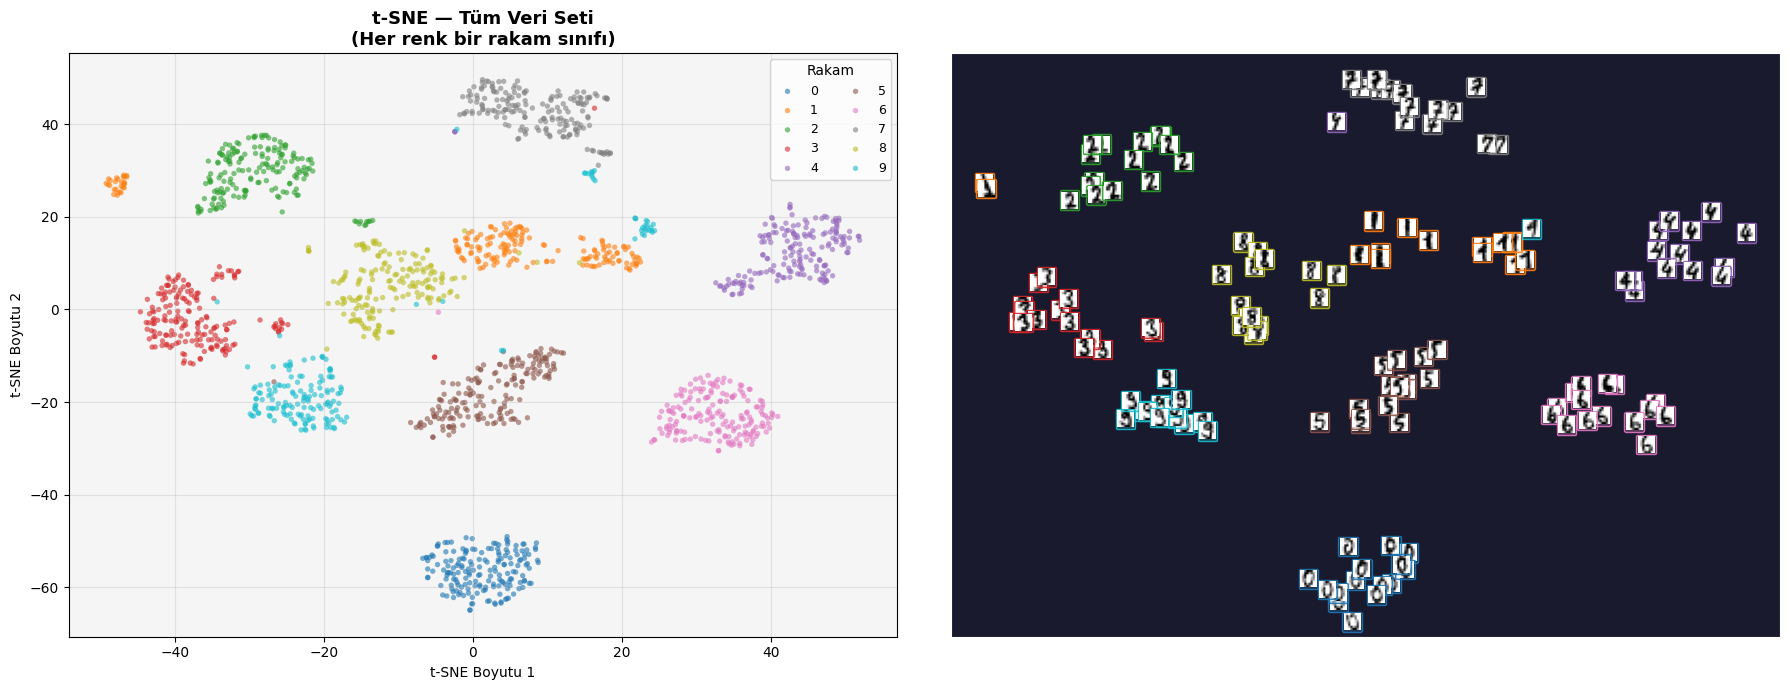


💡 t-SNE'de: Birbirinden ayrışan kümeler = model kolayca ayırt edebilir demektir.


In [6]:

# Önce PCA ile 30 boyuta indir (t-SNE hızlanır), sonra t-SNE ile 2 boyuta
print("Adım 1: PCA ile 30 boyuta indir...")
pca30 = PCA(n_components=30, random_state=42)
X_pca30 = pca30.fit_transform(X_flat)         # (1797, 64) → (1797, 30)
print(f"  PCA sonrası: {X_pca30.shape}")

print("Adım 2: t-SNE ile 2 boyuta indir (bu biraz sürebilir)...")
tsne = TSNE(
    n_components=2,       # 2D'ye yansıt
    perplexity=30,        # Yerel komşu sayısı (5-50 arası tavsiye)
    max_iter=1000,          # İterasyon sayısı
    random_state=42,      # Tekrar üretilebilirlik
    learning_rate='auto', # Otomatik öğrenme hızı
    init='pca'            # PCA başlangıcı → daha stabil yakınsama
)
X_tsne = tsne.fit_transform(X_pca30)          # (1797, 30) → (1797, 2)
print(f"  t-SNE sonrası: {X_tsne.shape}")

# ── Görselleştir ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = plt.cm.tab10(np.linspace(0, 1, 10))   # 10 sınıf için 10 farklı renk

# Sol: t-SNE scatter plot
for digit in range(10):
    mask = y_digits == digit                    # Bu rakama ait noktaların maskesi
    axes[0].scatter(
        X_tsne[mask, 0],                        # X koordinatı
        X_tsne[mask, 1],                        # Y koordinatı
        c=[colors[digit]],
        label=str(digit),
        alpha=0.6,                              # Şeffaflık — üst üste binen noktalar görülsün
        s=15,                                   # Nokta boyutu
        edgecolors='none'
    )

axes[0].set_title("t-SNE — Tüm Veri Seti\n(Her renk bir rakam sınıfı)",
                  fontsize=13, fontweight='bold')
axes[0].legend(title="Rakam", ncol=2, fontsize=9, loc='upper right')
axes[0].set_xlabel("t-SNE Boyutu 1")
axes[0].set_ylabel("t-SNE Boyutu 2")
axes[0].set_facecolor('#f5f5f5')
axes[0].grid(True, alpha=0.3)

# Sağ: t-SNE üzerine gerçek rakam görüntüleri koy (örnekleme ile)
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title("t-SNE — Gerçek Görüntülerle\n(Her nokta gerçek piksel değeri)",
                  fontsize=13, fontweight='bold', color='white')

# Her sınıftan 15 örnek seç
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

rng = np.random.default_rng(0)
for digit in range(10):
    mask_idx = np.where(y_digits == digit)[0]
    sample_indices = rng.choice(mask_idx, size=min(15, len(mask_idx)), replace=False)
    
    for idx in sample_indices:
        img = X_digits[idx]                         # 8×8 görüntü
        x, y_pos = X_tsne[idx, 0], X_tsne[idx, 1]  # t-SNE koordinatları
        
        # Görüntüyü renklendir (sınıfa göre)
        colored = plt.cm.tab10(digit / 10)[:3]      # RGB renk
        
        imagebox = OffsetImage(img, zoom=1.5, cmap='gray_r')   # Görüntü kutusu
        ab = AnnotationBbox(imagebox, (x, y_pos),
                            frameon=True,
                            bboxprops=dict(
                                boxstyle='round,pad=0.1',
                                facecolor=(*colored, 0.3),   # Yarı şeffaf renkli çerçeve
                                edgecolor=(*colored, 0.9),
                                linewidth=1.0
                            ))
        axes[1].add_artist(ab)                       # Sahneye ekle

axes[1].set_xlim(X_tsne[:,0].min()-3, X_tsne[:,0].max()+3)
axes[1].set_ylim(X_tsne[:,1].min()-3, X_tsne[:,1].max()+3)
axes[1].tick_params(colors='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('white')

plt.tight_layout()
plt.show()
print("\n💡 t-SNE'de: Birbirinden ayrışan kümeler = model kolayca ayırt edebilir demektir.")


## 🔬 Bölüm 16 — Konvolüsyon Katmanı Sıfırdan (NumPy)

CNN'in kalbi: **konvolüsyon işlemi.** Bir kernel görüntü üzerinde kaydırılır,
her konumda element-wise çarpım + toplam yapılır.

```
Output[i,j] = Σ Σ Input[i+m, j+n] × Kernel[m, n]
```

Bu bölümde PyTorch/TF kullanmadan, **saf NumPy** ile konvolüsyon yazacağız.


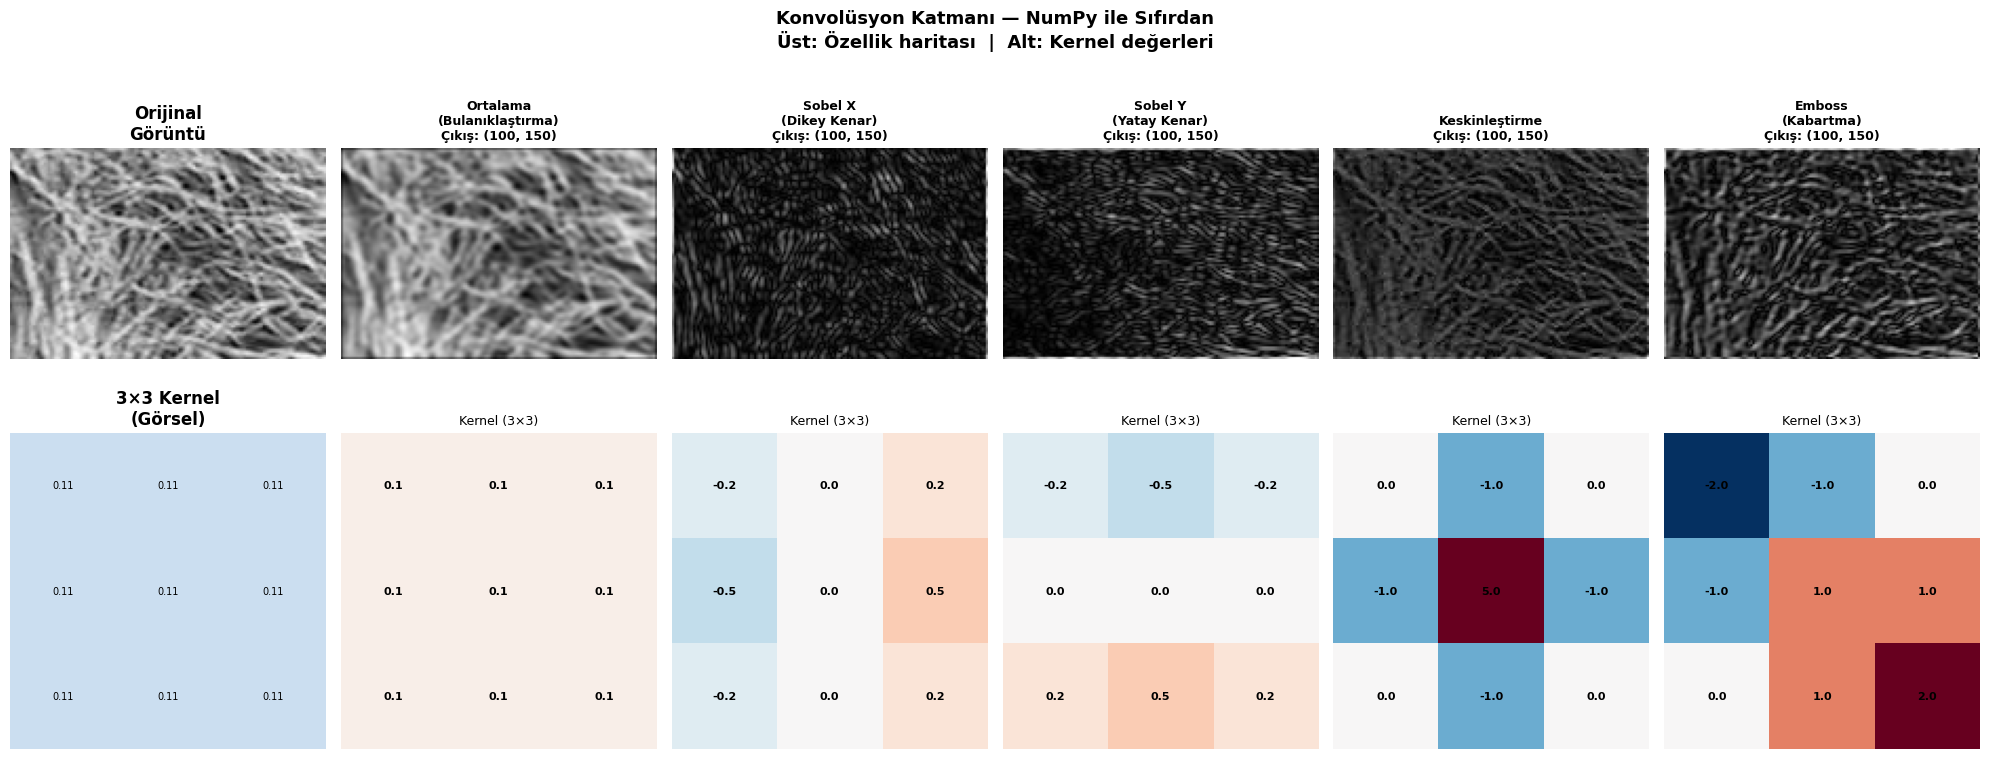

In [7]:

def conv2d_numpy(image, kernel, stride=1, padding=0):
    # #     2D Konvolüsyon — NumPy ile sıfırdan implementasyon.
    #     
    #     Parametreler:
    #       image  : (H, W) gri görüntü
    #       kernel : (kH, kW) filtre ağırlıkları
    #       stride : her adımda kaç piksel kayacak (default=1)
    #       padding: kenarlara kaç piksel sıfır eklenecek (default=0)
    #     
    #     Döner: (H_out, W_out) özellik haritası
    #
    H, W   = image.shape                          # Giriş boyutları
    kH, kW = kernel.shape                         # Kernel boyutları
    
    # Padding uygula — görüntünün etrafına sıfır satır/sütun ekle
    if padding > 0:
        image = np.pad(image,                     # Dizi
                       ((padding, padding),       # Dikey padding (üst, alt)
                        (padding, padding)),       # Yatay padding (sol, sağ)
                       mode='constant',            # Sabit değer ile doldur
                       constant_values=0)          # Sıfır ile doldur
        H, W = image.shape                        # Yeni boyutları güncelle
    
    # Çıkış boyutunu hesapla
    H_out = (H - kH) // stride + 1               # Yükseklik formülü
    W_out = (W - kW) // stride + 1               # Genişlik formülü
    output = np.zeros((H_out, W_out))             # Çıkış matrisi (sıfırla başlat)
    
    # Konvolüsyon döngüsü
    for i in range(H_out):                        # Her satır için
        for j in range(W_out):                    # Her sütun için
            # Kernel ile örtüşen bölgeyi al
            patch = image[i*stride : i*stride+kH,    # Satır dilimleme
                          j*stride : j*stride+kW]    # Sütun dilimleme
            # Element-wise çarpım ve topla → tek skalar
            output[i, j] = np.sum(patch * kernel)   # ★ Konvolüsyon operasyonu
    
    return output

# ── Farklı kernel'ları test et ────────────────────────────────────────────────
# Test görüntüsü: gerçek fotoğrafın gri versiyonu
test_img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY).astype(float)
test_crop = test_img_gray[100:200, 200:350]     # 100×150 bölge (hız için küçük)

# Tanımlı kernel'lar
kernels = {
    'Ortalama\n(Bulanıklaştırma)': np.ones((3,3)) / 9,       # Tüm komşuların eşit ortalaması
    'Sobel X\n(Dikey Kenar)':      np.array([[-1,0,1],       # Yatay gradyan
                                              [-2,0,2],
                                              [-1,0,1]]) / 4.0,
    'Sobel Y\n(Yatay Kenar)':      np.array([[-1,-2,-1],     # Dikey gradyan
                                              [ 0, 0, 0],
                                              [ 1, 2, 1]]) / 4.0,
    'Keskinleştirme':              np.array([[ 0,-1, 0],     # Laplacian keskinleştirme
                                              [-1, 5,-1],
                                              [ 0,-1, 0]]),
    'Emboss\n(Kabartma)':          np.array([[-2,-1, 0],     # Emboss efekti
                                              [-1, 1, 1],
                                              [ 0, 1, 2]]),
}

fig, axes = plt.subplots(2, len(kernels)+1, figsize=(20, 8))

# Orijinal
axes[0,0].imshow(test_crop, cmap='gray')
axes[0,0].set_title("Orijinal\nGörüntü", fontweight='bold')
axes[0,0].axis('off')

axes[1,0].imshow(np.ones((3,3))/9, cmap='Blues', vmin=0, vmax=0.5)
axes[1,0].set_title("3×3 Kernel\n(Görsel)", fontweight='bold')
for ki in range(3):
    for kj in range(3):
        axes[1,0].text(kj, ki, f"{(np.ones((3,3))/9)[ki,kj]:.2f}",
                       ha='center', va='center', fontsize=7)
axes[1,0].axis('off')

for col, (name, kernel) in enumerate(kernels.items(), start=1):
    # Konvolüsyon uygula (numpy implementasyonu)
    result = conv2d_numpy(test_crop, kernel, padding=1)
    
    # Görüntüyü göster (mutlak değer al ve normalize et)
    display = np.abs(result)
    display = (display - display.min()) / (display.max() - display.min() + 1e-8) * 255
    
    axes[0, col].imshow(display.astype(np.uint8), cmap='gray')
    axes[0, col].set_title(f"{name}\nÇıkış: {result.shape}", fontsize=9, fontweight='bold')
    axes[0, col].axis('off')
    
    # Kernel görselleştir
    axes[1, col].imshow(kernel, cmap='RdBu_r', vmin=-2, vmax=2)
    for ki in range(3):
        for kj in range(3):
            axes[1, col].text(kj, ki, f"{kernel[ki,kj]:.1f}",
                             ha='center', va='center', fontsize=8, fontweight='bold')
    axes[1, col].set_title(f"Kernel ({kernel.shape[0]}×{kernel.shape[1]})", fontsize=9)
    axes[1, col].axis('off')

plt.suptitle("Konvolüsyon Katmanı — NumPy ile Sıfırdan\nÜst: Özellik haritası  |  Alt: Kernel değerleri",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## ⚡ Bölüm 17 — Aktivasyon Fonksiyonları ve Özellik Haritaları

Konvolüsyon → **Aktivasyon** → Havuzlama (Pooling) — CNN'in temel bloğu.

Aktivasyon **lineer olmayan** bir fonksiyon koyar; olmadan tüm katmanlar
tek bir lineer dönüşüme indirgenirdi (derinlik anlamsız olurdu).

| Fonksiyon | Formül | Kullanım |
|-----------|--------|---------|
| **ReLU** | max(0, x) | CNN standart aktivasyonu |
| **Sigmoid** | 1/(1+e⁻ˣ) | İkili sınıflandırma çıkışı |
| **Tanh** | (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ) | RNN gizli katmanları |
| **Leaky ReLU** | x>0→x, x<0→0.01x | Ölü ReLU sorununu çözer |


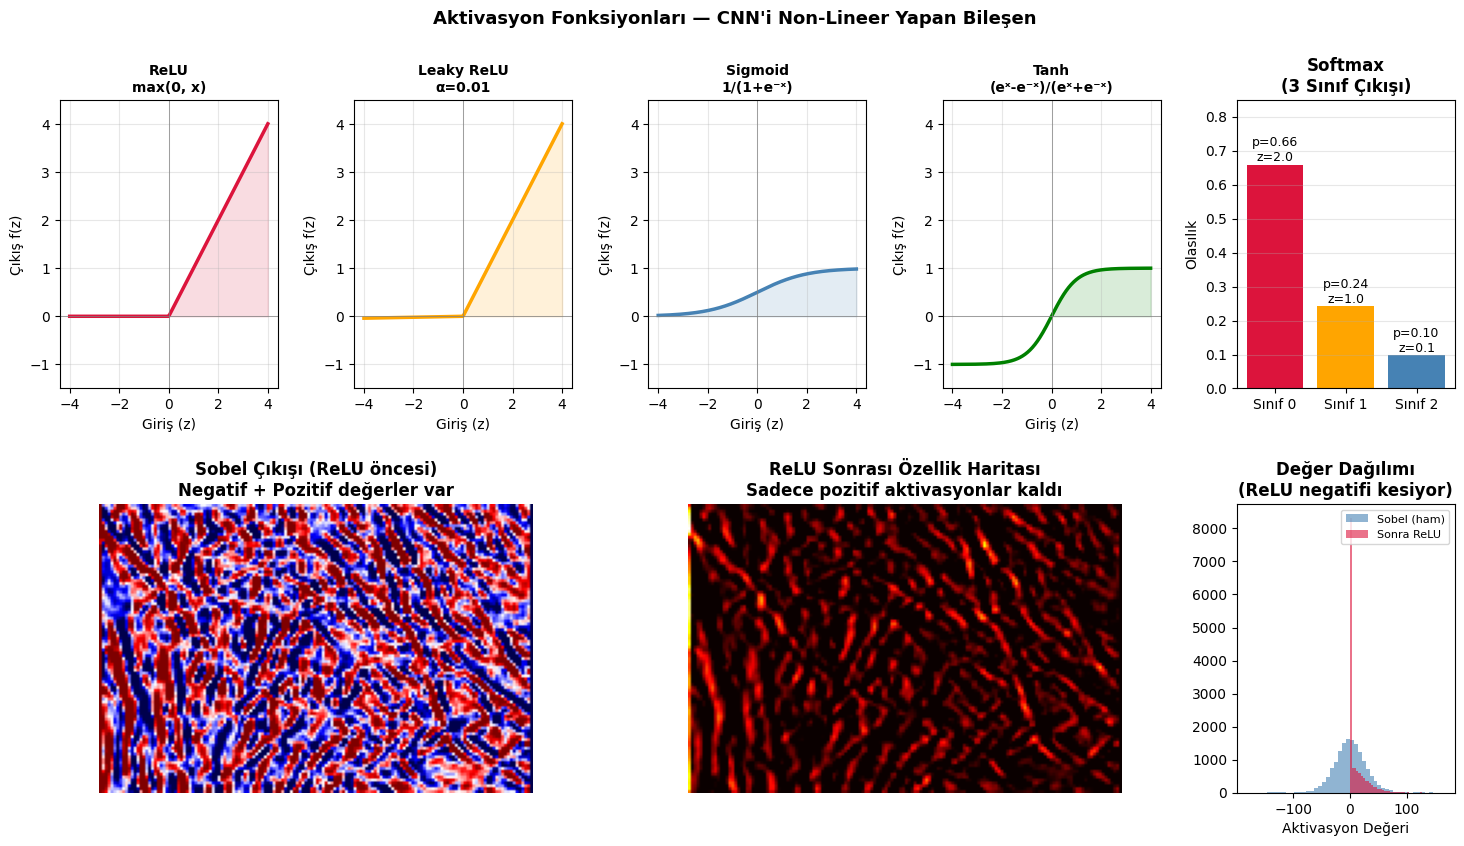

In [8]:

# ── Aktivasyon fonksiyonlarını tanımla ────────────────────────────────────────
def relu(x):
    # ReLU: Negatif değerleri sıfırlar, pozitifler değişmez.
    return np.maximum(0, x)                    # Her elemana max(0, x) uygula

def leaky_relu(x, alpha=0.01):
    # Leaky ReLU: Negatifler için küçük bir eğim (alpha) bırakır.
    return np.where(x > 0, x, alpha * x)      # Pozitif → x, Negatif → 0.01*x

def sigmoid(x):
    # Sigmoid: Çıktıyı [0,1] aralığına sıkıştırır.
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Overflow'u önle

def tanh(x):
    # Tanh: Çıktıyı [-1,1] aralığına sıkıştırır.
    return np.tanh(x)

def softmax(x):
    # Softmax: Tüm çıktıların toplamı 1 olacak şekilde normalize eder (olasılık).
    e_x = np.exp(x - np.max(x))              # Stabilite için max'ı çıkar
    return e_x / e_x.sum()

# ── Aktivasyon fonksiyonlarını çiz ────────────────────────────────────────────
x = np.linspace(-4, 4, 400)                  # -4'ten 4'e 400 nokta

fig = plt.figure(figsize=(18, 9))
gs  = GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.35)

activations = [
    ('ReLU\nmax(0, x)', relu(x), 'crimson'),
    ('Leaky ReLU\nα=0.01', leaky_relu(x), 'orange'),
    ('Sigmoid\n1/(1+e⁻ˣ)', sigmoid(x), 'steelblue'),
    ('Tanh\n(eˣ-e⁻ˣ)/(eˣ+e⁻ˣ)', tanh(x), 'green'),
    ('Softmax\n(örnek 3 sınıf)', None, 'purple'),
]

# İlk 4 aktivasyonu çiz
for i, (name, y_act, color) in enumerate(activations[:4]):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(x, y_act, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5)     # Y=0 çizgisi
    ax.axvline(0, color='gray', linewidth=0.5)     # X=0 çizgisi
    ax.fill_between(x, y_act, 0, where=(y_act > 0), alpha=0.15, color=color)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Giriş (z)")
    ax.set_ylabel("Çıkış f(z)")
    ax.set_ylim(-1.5, 4.5)
    ax.grid(True, alpha=0.3)

# Softmax örneği
ax_sm = fig.add_subplot(gs[0, 4])
logits = np.array([2.0, 1.0, 0.1])           # Ham skor (logit) — 3 sınıf
probs  = softmax(logits)                      # Olasılıklara dönüştür
bars   = ax_sm.bar(['Sınıf 0', 'Sınıf 1', 'Sınıf 2'], probs,
                    color=['crimson','orange','steelblue'])
for bar, p, l in zip(bars, probs, logits):
    ax_sm.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f'p={p:.2f}\nz={l}', ha='center', fontsize=9)
ax_sm.set_title('Softmax\n(3 Sınıf Çıkışı)', fontweight='bold')
ax_sm.set_ylabel('Olasılık')
ax_sm.set_ylim(0, 0.85)
ax_sm.grid(True, alpha=0.3, axis='y')

# Alt satır: Gerçek görüntü üzerinde ReLU aktivasyonu
test_slice = test_img_gray[100:200, 200:350]
sobel_out  = conv2d_numpy(test_slice, np.array([[-1,0,1],[-2,0,2],[-1,0,1]])/4.0, padding=1)

ax_raw  = fig.add_subplot(gs[1, 0:2])
ax_relu = fig.add_subplot(gs[1, 2:4])
ax_hist = fig.add_subplot(gs[1, 4])

ax_raw.imshow(sobel_out, cmap='seismic', vmin=-30, vmax=30)
ax_raw.set_title("Sobel Çıkışı (ReLU öncesi)\nNegatif + Pozitif değerler var", fontweight='bold')
ax_raw.axis('off')

relu_out = relu(sobel_out)                    # Negatif değerleri sıfırla
ax_relu.imshow(relu_out, cmap='hot')
ax_relu.set_title("ReLU Sonrası Özellik Haritası\nSadece pozitif aktivasyonlar kaldı", fontweight='bold')
ax_relu.axis('off')

ax_hist.hist(sobel_out.flatten(), bins=50, alpha=0.6, color='steelblue', label='Sobel (ham)')
ax_hist.hist(relu_out.flatten(),  bins=50, alpha=0.6, color='crimson',   label='Sonra ReLU')
ax_hist.set_title("Değer Dağılımı\n(ReLU negatifi kesiyor)", fontweight='bold')
ax_hist.legend(fontsize=8)
ax_hist.set_xlabel("Aktivasyon Değeri")

plt.suptitle("Aktivasyon Fonksiyonları — CNN'i Non-Lineer Yapan Bileşen",
             fontsize=13, fontweight='bold')
plt.show()


## 🧠 Bölüm 18 — Çok Katmanlı Sinir Ağı (MLP) — Derinlemesine

MLP (Multilayer Perceptron): Giriş → Gizli Katmanlar → Çıkış

```
Giriş (64)  →  [Dense 256, ReLU]  →  [Dense 128, ReLU]  →  [Dense 64, ReLU]  →  Çıkış (10, Softmax)
```

**Hiperparametre etkilerini** ve **öğrenme eğrisini** inceleyelim.


Yüzeysel (1 katman)       | Eğitim: 97.0%  Test: 94.7%  Parametre: 4,810  İter: 38


Orta (2 katman)           | Eğitim: 98.7%  Test: 95.8%  Parametre: 17,226  İter: 29


Derin (3 katman)          | Eğitim: 99.9%  Test: 97.8%  Parametre: 58,442  İter: 36


Çok Derin (4 katman)      | Eğitim: 99.8%  Test: 97.1%  Parametre: 206,410  İter: 21


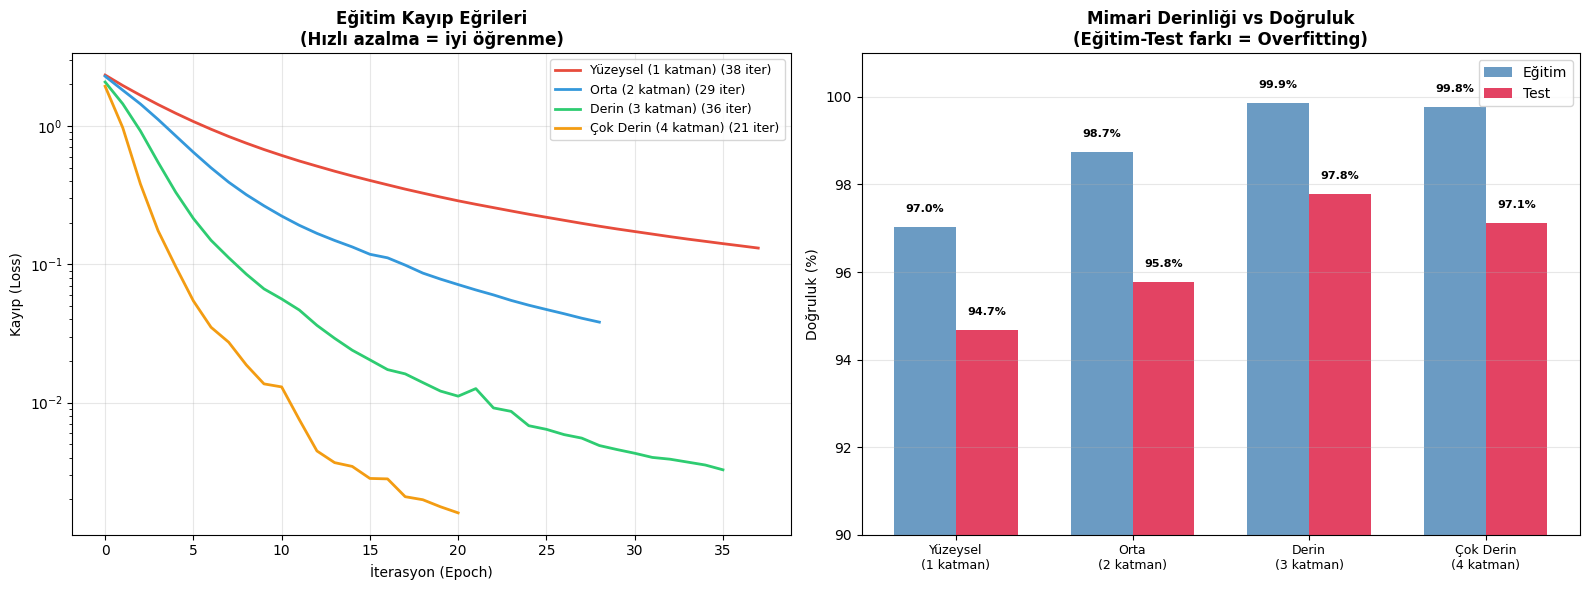

In [9]:

# ── Farklı Mimari Derinlikleri Karşılaştır ────────────────────────────────────
architectures = {
    'Yüzeysel\n(1 katman)': (64,),
    'Orta\n(2 katman)': (128, 64),
    'Derin\n(3 katman)': (256, 128, 64),
    'Çok Derin\n(4 katman)': (512, 256, 128, 64),
}

results_arch = {}
for arch_name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',             # ReLU aktivasyonu
        solver='adam',                 # Adam optimizer
        alpha=1e-4,                    # L2 regularizasyon katsayısı
        max_iter=200,
        random_state=42,
        early_stopping=True,           # Validation loss artarsa dur
        validation_fraction=0.1        # %10'unu validasyon için ayır
    )
    mlp.fit(X_train_sc, y_train)       # Eğit
    
    train_acc = accuracy_score(y_train, mlp.predict(X_train_sc))
    test_acc  = accuracy_score(y_test,  mlp.predict(X_test_sc))
    n_params  = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
    
    results_arch[arch_name] = {
        'model': mlp,
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'n_iter':    mlp.n_iter_,
        'n_params':  n_params,
        'loss_curve': mlp.loss_curve_
    }
    print(f"{arch_name.replace(chr(10), ' '):<25} | Eğitim: {train_acc*100:.1f}%  "
          f"Test: {test_acc*100:.1f}%  Parametre: {n_params:,}  İter: {mlp.n_iter_}")

# ── Öğrenme Eğrilerini Çiz ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_arch = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for (name, res), color in zip(results_arch.items(), colors_arch):
    axes[0].plot(res['loss_curve'], color=color, linewidth=2,
                 label=f"{name.replace(chr(10),' ')} ({res['n_iter']} iter)")

axes[0].set_xlabel("İterasyon (Epoch)")
axes[0].set_ylabel("Kayıp (Loss)")
axes[0].set_title("Eğitim Kayıp Eğrileri\n(Hızlı azalma = iyi öğrenme)", fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_yscale('log')                     # Log ölçeği — küçük farkları görünür kılar
axes[0].grid(True, alpha=0.3)

# Mimari karşılaştırma çubuk grafiği
x_pos    = np.arange(len(results_arch))
tr_accs  = [r['train_acc']*100 for r in results_arch.values()]
te_accs  = [r['test_acc']*100  for r in results_arch.values()]
bar_w    = 0.35

bars1 = axes[1].bar(x_pos - bar_w/2, tr_accs, bar_w,
                    label='Eğitim', color='steelblue', alpha=0.8)
bars2 = axes[1].bar(x_pos + bar_w/2, te_accs, bar_w,
                    label='Test',   color='crimson', alpha=0.8)

# Değerleri çubukların üstüne yaz
for bar, val in zip(list(bars1)+list(bars2), tr_accs+te_accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace('\n', '\n') for n in results_arch.keys()], fontsize=9)
axes[1].set_ylabel("Doğruluk (%)")
axes[1].set_title("Mimari Derinliği vs Doğruluk\n(Eğitim-Test farkı = Overfitting)", fontweight='bold')
axes[1].legend()
axes[1].set_ylim(90, 101)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 🏆 Bölüm 19 — SVM vs MLP vs KNN — Kapsamlı Karşılaştırma

Aynı veri seti üzerinde üç farklı algoritmayı **cross-validation** ile adil biçimde karşılaştır.


5-Fold Cross Validation başlıyor...

Model              CV Mean     CV Std   Süre (s)
──────────────────────────────────────────────────
KNN (k=5)           98.05%       0.50%        0.0s


SVM (RBF)           98.39%       0.67%        1.2s


MLP                 97.61%       0.22%        5.3s


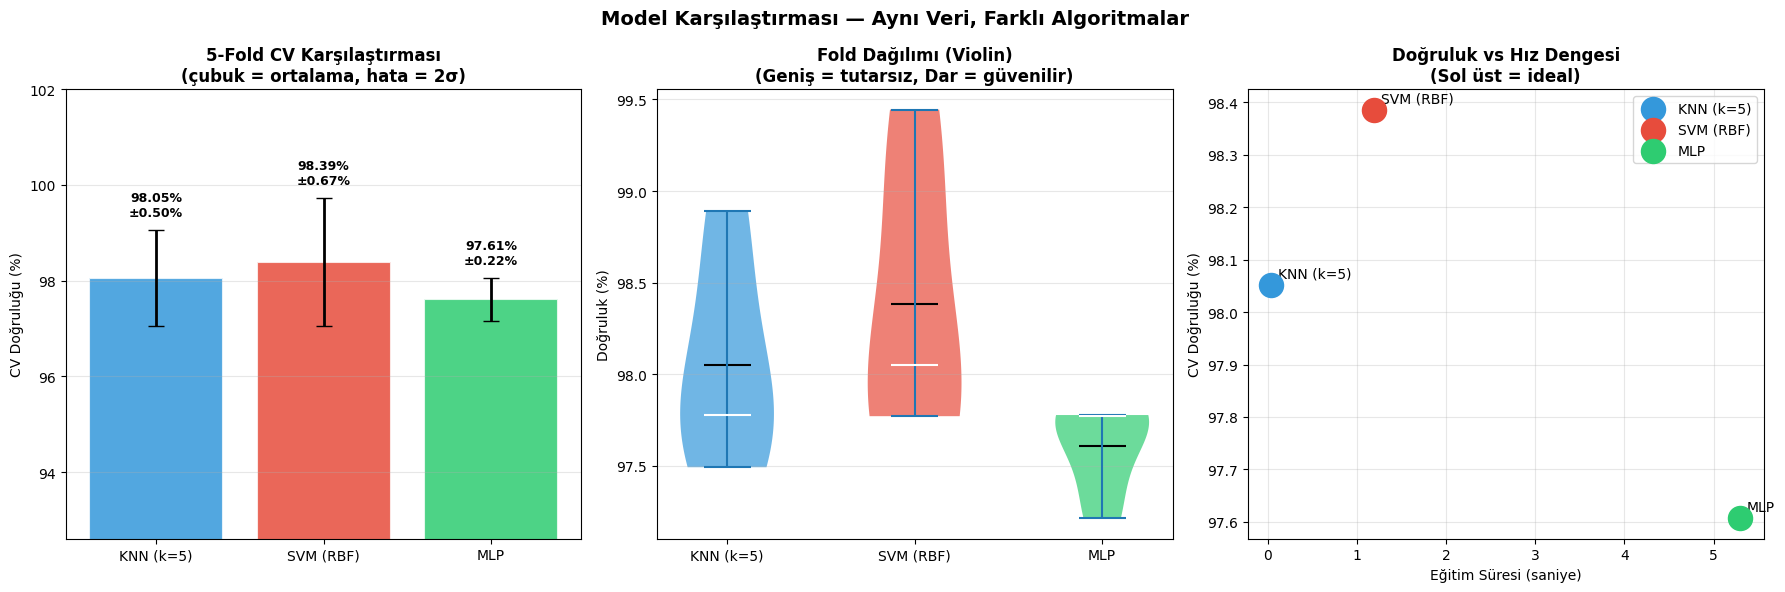

In [10]:

from sklearn.model_selection import StratifiedKFold
import time

# ── Pipeline'lar oluştur (Scaler + Model) ────────────────────────────────────
pipelines = {
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=5, weights='distance'))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
    ]),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42))
    ]),
}

# ── 5-Fold Cross Validation ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold: Her fold'da sınıf dağılımı korunur

cv_results = {}
print("5-Fold Cross Validation başlıyor...\n")
print(f"{'Model':<15} {'CV Mean':>10} {'CV Std':>10} {'Süre (s)':>10}")
print("─" * 50)

for name, pipe in pipelines.items():
    t0     = time.time()
    scores = cross_val_score(pipe, X_flat, y_digits, cv=cv,
                             scoring='accuracy', n_jobs=-1)  # Tüm CPU kullan
    elapsed = time.time() - t0
    
    cv_results[name] = {
        'scores': scores,
        'mean':   scores.mean(),
        'std':    scores.std(),
        'time':   elapsed
    }
    print(f"{name:<15} {scores.mean()*100:>9.2f}%  {scores.std()*100:>9.2f}%  {elapsed:>9.1f}s")

# ── Sonuçları Görselleştir ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

names   = list(cv_results.keys())
means   = [cv_results[n]['mean']*100 for n in names]
stds    = [cv_results[n]['std']*100  for n in names]
times   = [cv_results[n]['time']     for n in names]
palette = ['#3498db', '#e74c3c', '#2ecc71']

# Sol: CV Doğruluk + Hata çubuğu
bars = axes[0].bar(names, means, color=palette, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].errorbar(names, means, yerr=[2*s for s in stds],   # 2σ hata payı
                 fmt='none', color='black', capsize=6, linewidth=2)
for bar, m, s in zip(bars, means, stds):
    axes[0].text(bar.get_x()+bar.get_width()/2, m+2*s+0.3,
                 f'{m:.2f}%\n±{s:.2f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel("CV Doğruluğu (%)")
axes[0].set_title("5-Fold CV Karşılaştırması\n(çubuk = ortalama, hata = 2σ)", fontweight='bold')
axes[0].set_ylim(min(means)-5, 102)
axes[0].grid(True, alpha=0.3, axis='y')

# Orta: Violin plot — Dağılım
positions = range(len(names))
all_scores = [cv_results[n]['scores']*100 for n in names]
vp = axes[1].violinplot(all_scores, positions=positions, showmeans=True, showmedians=True)

for i, (pc, color) in enumerate(zip(vp['bodies'], palette)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('white')

axes[1].set_xticks(positions)
axes[1].set_xticklabels(names)
axes[1].set_ylabel("Doğruluk (%)")
axes[1].set_title("Fold Dağılımı (Violin)\n(Geniş = tutarsız, Dar = güvenilir)", fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Sağ: Doğruluk vs Hız
scatter_colors = palette
for i, (name, m, t, color) in enumerate(zip(names, means, times, scatter_colors)):
    axes[2].scatter(t, m, s=300, color=color, zorder=5, label=name)
    axes[2].annotate(name, (t, m), textcoords="offset points", xytext=(5, 5), fontsize=10)

axes[2].set_xlabel("Eğitim Süresi (saniye)")
axes[2].set_ylabel("CV Doğruluğu (%)")
axes[2].set_title("Doğruluk vs Hız Dengesi\n(Sol üst = ideal)", fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle("Model Karşılaştırması — Aynı Veri, Farklı Algoritmalar",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔥 Bölüm 20 — Saliency Map (Modelin Neye Baktığı)

**Grad-CAM / Saliency Maps:** Modelin bir kararı verirken hangi piksellere odaklandığını gösterir.

Yaklaşım: Giriş piksellerini birer birer küçük miktarda değiştir, çıkış olasılığı
ne kadar değişirse o piksel **o kadar önemlidir**.

> Gerçek Grad-CAM gradyan gerektirir (PyTorch/TF). Biz burada **perturbation-based** yöntemi kullanıyoruz.


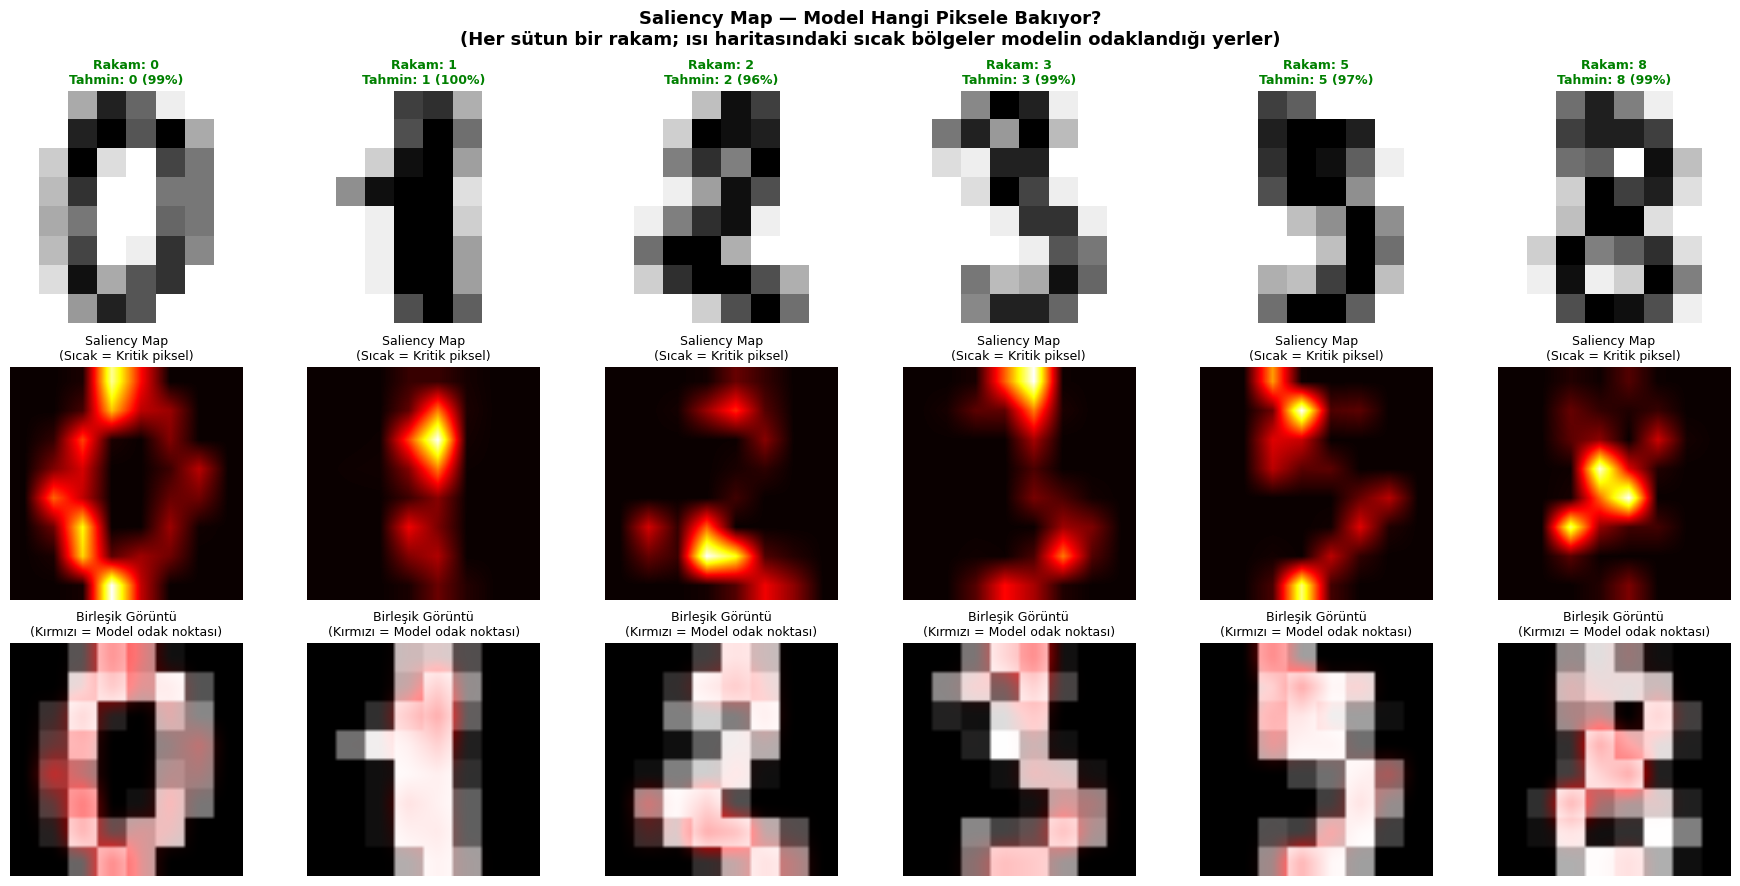

In [11]:

# ── En iyi modeli (SVM) test setine fit et ────────────────────────────────────
best_model = pipelines['SVM (RBF)']
best_model.fit(X_flat, y_digits)              # Tüm veri ile yeniden eğit

def saliency_map_perturbation(model, image_flat, target_class, n_pixels=64):
    # #     Perturbation tabanlı saliency map.
    #     Her piksel sırayla sıfırlanır (maskelenir), olasılık değişimi ölçülür.
    #     
    #     Args:
    #         model       : fit edilmiş sklearn modeli (predict_proba desteklemeli)
    #         image_flat  : (64,) düzleştirilmiş görüntü
    #         target_class: hangi sınıfın önemini ölç
    #     Returns:
    #         (8, 8) saliency haritası
    #
    # Orijinal tahmin olasılığı
    base_prob = model.predict_proba([image_flat])[0][target_class]
    
    saliency = np.zeros(n_pixels)              # Her piksel için önem skoru
    
    for i in range(n_pixels):                 # Her piksel için
        perturbed = image_flat.copy()         # Görüntüyü kopyala
        perturbed[i] = 0                      # i. pikseli sıfırla (maskele)
        
        # Maskelenmiş görüntünün olasılığı
        perturbed_prob = model.predict_proba([perturbed])[0][target_class]
        
        # Olasılık düşüşü = pikselin önemi
        saliency[i] = base_prob - perturbed_prob   # Pozitif → piksel kritik
    
    return saliency.reshape(8, 8)             # 1D → 8×8

# ── Farklı rakamlar için saliency map üret ────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
test_digits_to_show = [0, 1, 2, 3, 5, 8]     # 6 farklı rakam

for col, digit in enumerate(test_digits_to_show):
    # Bu rakam sınıfından doğru tahmin edilen bir örnek bul
    candidates = np.where((y_digits == digit))[0]
    img_idx    = candidates[0]
    img_flat   = X_flat[img_idx]
    img_2d     = X_digits[img_idx]
    
    pred_class = best_model.predict([img_flat])[0]   # Modelin tahmini
    pred_prob  = best_model.predict_proba([img_flat])[0]
    
    # Saliency map hesapla
    sal_map = saliency_map_perturbation(best_model, img_flat, digit)
    
    # ── Orijinal görüntü ──────────────────────────────────────────────────
    axes[0, col].imshow(img_2d, cmap='gray_r', interpolation='nearest')
    axes[0, col].set_title(
        f"Rakam: {digit}\nTahmin: {pred_class} ({pred_prob[pred_class]*100:.0f}%)",
        fontsize=9, fontweight='bold',
        color='green' if pred_class == digit else 'red'
    )
    axes[0, col].axis('off')
    axes[0, col].set_xticks(np.arange(-0.5, 8, 1), minor=True)
    axes[0, col].set_yticks(np.arange(-0.5, 8, 1), minor=True)
    axes[0, col].grid(which='minor', color='white', linewidth=0.5)
    
    # ── Saliency haritası ─────────────────────────────────────────────────
    sal_clipped = np.clip(sal_map, 0, None)   # Negatif değerleri sıfırla
    im = axes[1, col].imshow(sal_clipped, cmap='hot',  # Isı haritası
                              interpolation='bilinear')
    axes[1, col].set_title(f"Saliency Map\n(Sıcak = Kritik piksel)", fontsize=9)
    axes[1, col].axis('off')
    
    # ── Üst üste bindirme (Overlay) ───────────────────────────────────────
    # Orijinal görüntüyü [0,1]'e normalize et
    img_norm = (img_2d - img_2d.min()) / (img_2d.max() - img_2d.min() + 1e-8)
    # Büyük versiyon için resize (görselleştirme kalitesi)
    img_big  = cv2.resize(img_norm, (64, 64), interpolation=cv2.INTER_NEAREST)
    sal_big  = cv2.resize(sal_clipped, (64, 64), interpolation=cv2.INTER_LINEAR)
    sal_norm = (sal_big - sal_big.min()) / (sal_big.max() - sal_big.min() + 1e-8)
    
    # RGB overlay: gri görüntü üstüne kırmızı saliency
    overlay        = np.stack([img_big]*3, axis=-1)   # Gri → RGB
    overlay[:,:,0] = np.clip(img_big + sal_norm * 0.8, 0, 1)  # Kırmızı kanalı artır
    overlay[:,:,1] = np.clip(img_big - sal_norm * 0.3, 0, 1)  # Yeşil kanalı azalt
    overlay[:,:,2] = np.clip(img_big - sal_norm * 0.3, 0, 1)  # Mavi kanalı azalt
    
    axes[2, col].imshow(overlay, interpolation='bilinear')
    axes[2, col].set_title("Birleşik Görüntü\n(Kırmızı = Model odak noktası)", fontsize=9)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel("Orijinal", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Saliency", fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel("Overlay", fontsize=11, fontweight='bold')

plt.suptitle("Saliency Map — Model Hangi Piksele Bakıyor?\n"
             "(Her sütun bir rakam; ısı haritasındaki sıcak bölgeler modelin odaklandığı yerler)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ Bölüm 21 — Tam CNN Pipeline — Sıfırdan İleri Yayılım

PyTorch/TensorFlow olmadan, **saf NumPy** ile:
1. Konvolüsyon katmanı
2. ReLU aktivasyonu
3. Max Pooling
4. Flatten
5. Tam bağlı katman (Dense)
6. Softmax çıkışı

**Geri yayılım (backprop)** bu aşamada dahil değil; sadece ileri yayılım (inference).
Amaç: CNN'in içini anlamak.


In [12]:

class SimpleCNN:
    # #     Saf NumPy CNN — İleri Yayılım (Forward Pass) Implementasyonu
    #     
    #     Mimari:
    #     Input (8×8) → Conv(3×3, 4 filtre) → ReLU → MaxPool(2×2) → Flatten → Dense(10) → Softmax
    #
    
    def __init__(self, n_filters=4, seed=42):
        rng = np.random.default_rng(seed)
        
        # ── Konvolüsyon katmanı ağırlıkları ─────────────────────────────────
        # n_filters adet 3×3 filtre; Her filtre farklı bir özelliği öğrenir
        self.conv_kernels = rng.standard_normal((n_filters, 3, 3)) * 0.1  # (4, 3, 3)
        self.conv_biases  = np.zeros(n_filters)                            # (4,)
        
        # ── Tam bağlı katman ağırlıkları ────────────────────────────────────
        # MaxPool(2×2) sonrası: 8×8 → Conv(pad=1) → 8×8 → Pool → 4×4
        # 4 filtre × 4 × 4 = 64 özellik
        pooled_size = 4 * 4                                                # 4×4 havuzlama sonrası
        self.dense_W = rng.standard_normal((n_filters * pooled_size, 10)) * 0.1  # (64, 10)
        self.dense_b = np.zeros(10)                                        # (10,)
        
        self.n_filters = n_filters
        self.activations = {}                  # Her katmanın çıkışını sakla (görselleştirme için)
    
    def conv_layer(self, image):
        # #         Konvolüsyon katmanı: Her filtre görüntüyle konvolüsyon yapar.
    #         Döner: (n_filters, H, W) özellik haritaları yığını
    #
        feature_maps = []
        for i, kernel in enumerate(self.conv_kernels):
            # Padding=1 → görüntü boyutu korunur (same padding)
            fm = conv2d_numpy(image, kernel, padding=1)    # (8,8)
            fm = fm + self.conv_biases[i]                  # Bias ekle
            feature_maps.append(fm)
        return np.stack(feature_maps, axis=0)              # (n_filters, 8, 8)
    
    def relu_layer(self, x):
        # ReLU: Her elemana max(0, x) uygula.
        return np.maximum(0, x)
    
    def max_pool(self, feature_maps, pool_size=2, stride=2):
        # #         Max Pooling: Her pool_size × pool_size pencerede maksimum değeri al.
    #         Görüntüyü küçültür ve en önemli özellikleri korur.
    #
        n, H, W = feature_maps.shape
        H_out   = H // stride                              # Çıkış yüksekliği
        W_out   = W // stride                              # Çıkış genişliği
        pooled  = np.zeros((n, H_out, W_out))              # Çıkış dizisi
        
        for f in range(n):                                 # Her filtre için
            for i in range(H_out):
                for j in range(W_out):
                    # Pencere koordinatları
                    r0, r1 = i*stride, i*stride+pool_size
                    c0, c1 = j*stride, j*stride+pool_size
                    pooled[f, i, j] = feature_maps[f, r0:r1, c0:c1].max()  # En büyük değer
        return pooled
    
    def dense_layer(self, flat_input):
        # Tam bağlı katman: Matris çarpımı + bias.
        return flat_input @ self.dense_W + self.dense_b    # (64,) @ (64,10) = (10,)
    
    def softmax(self, logits):
        # Softmax: Logitleri olasılıklara çevir.
        e = np.exp(logits - logits.max())                  # Stabilite için max çıkar
        return e / e.sum()
    
    def forward(self, image):
        # Tam ileri yayılım — her katmanı sırayla uygula.
        self.activations['input'] = image                  # Girişi sakla
        
        conv_out  = self.conv_layer(image)                 # Conv: (4, 8, 8)
        self.activations['conv'] = conv_out
        
        relu_out  = self.relu_layer(conv_out)              # ReLU: (4, 8, 8)
        self.activations['relu'] = relu_out
        
        pool_out  = self.max_pool(relu_out)                # MaxPool: (4, 4, 4)
        self.activations['pool'] = pool_out
        
        flat_out  = pool_out.flatten()                     # Flatten: (64,)
        self.activations['flat'] = flat_out
        
        dense_out = self.dense_layer(flat_out)             # Dense: (10,)
        self.activations['dense'] = dense_out
        
        probs     = self.softmax(dense_out)                # Softmax: (10,) toplamı=1
        self.activations['output'] = probs
        
        return probs

# ── CNN'i bir görüntü üzerinde çalıştır ──────────────────────────────────────
cnn = SimpleCNN(n_filters=4)
sample = X_digits[0]                           # İlk görüntü: rakam 0
probs  = cnn.forward(sample)

print("=" * 50)
print(f"Giriş boyutu        : {sample.shape}")
print(f"Conv çıkışı         : {cnn.activations['conv'].shape}")
print(f"ReLU çıkışı         : {cnn.activations['relu'].shape}")
print(f"MaxPool çıkışı      : {cnn.activations['pool'].shape}")
print(f"Flatten çıkışı      : {cnn.activations['flat'].shape}")
print(f"Dense çıkışı        : {cnn.activations['dense'].shape}")
print(f"Softmax çıkışı      : {cnn.activations['output'].shape}  (toplam={probs.sum():.4f})")
print("=" * 50)
print(f"\nGerçek etiket: {y_digits[0]}")
print(f"Model tahmini: {np.argmax(probs)} (olasılık: {probs.max():.3f})")
print("\nTüm sınıf olasılıkları:")
for i, p in enumerate(probs):
    bar = "█" * int(p * 40)
    print(f"  Rakam {i}: {p:.4f}  {bar}")


Giriş boyutu        : (8, 8)
Conv çıkışı         : (4, 8, 8)
ReLU çıkışı         : (4, 8, 8)
MaxPool çıkışı      : (4, 4, 4)
Flatten çıkışı      : (64,)
Dense çıkışı        : (10,)
Softmax çıkışı      : (10,)  (toplam=1.0000)

Gerçek etiket: 0
Model tahmini: 6 (olasılık: 0.545)

Tüm sınıf olasılıkları:
  Rakam 0: 0.0259  █
  Rakam 1: 0.1032  ████
  Rakam 2: 0.0729  ██
  Rakam 3: 0.0293  █
  Rakam 4: 0.0342  █
  Rakam 5: 0.0453  █
  Rakam 6: 0.5447  █████████████████████
  Rakam 7: 0.0022  
  Rakam 8: 0.1096  ████
  Rakam 9: 0.0327  █


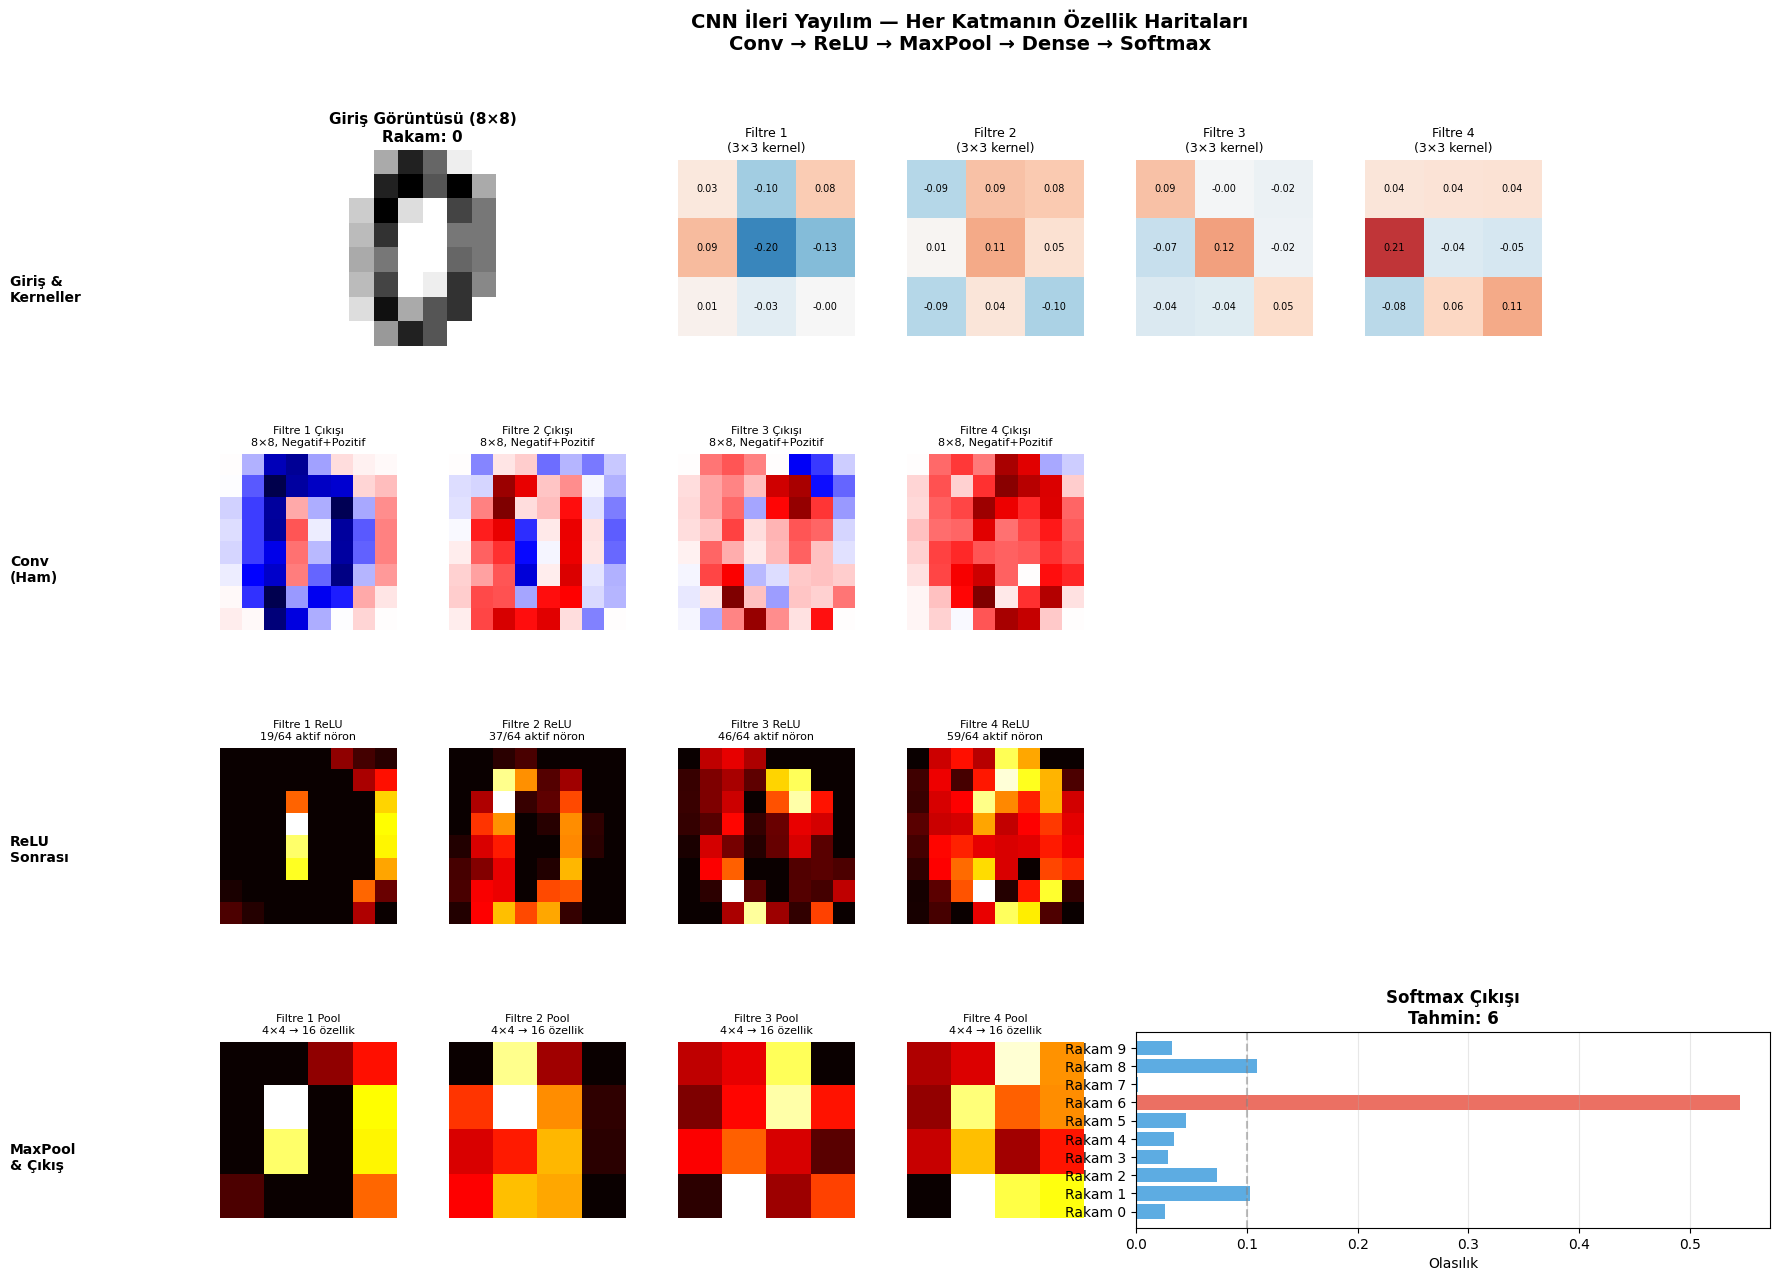

In [13]:

# ── CNN Özellik Haritalarını Görselleştir ─────────────────────────────────────
# Bu, bir gerçek CNN debug oturumunu simüle eder

fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(4, 7, figure=fig, hspace=0.5, wspace=0.3)

# Satır 0: Giriş görüntüsü
ax0 = fig.add_subplot(gs[0, :2])
ax0.imshow(sample, cmap='gray_r', interpolation='nearest')
ax0.set_title(f"Giriş Görüntüsü (8×8)\nRakam: {y_digits[0]}", fontweight='bold', fontsize=11)
ax0.axis('off')
ax0.set_xticks(np.arange(-0.5, 8, 1), minor=True)
ax0.set_yticks(np.arange(-0.5, 8, 1), minor=True)
ax0.grid(which='minor', color='white', linewidth=0.5)

# Kernel görüntüleri
for f in range(cnn.n_filters):
    ax = fig.add_subplot(gs[0, 2+f])
    ax.imshow(cnn.conv_kernels[f], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    for ki in range(3):
        for kj in range(3):
            ax.text(kj, ki, f"{cnn.conv_kernels[f][ki,kj]:.2f}",
                   ha='center', va='center', fontsize=7)
    ax.set_title(f"Filtre {f+1}\n(3×3 kernel)", fontsize=9)
    ax.axis('off')

fig.text(0.02, 0.78, "Giriş &\nKerneller", fontsize=10, fontweight='bold',
         va='center', rotation=0)

# Satır 1: Conv çıkışı (ham)
fig.text(0.02, 0.58, "Conv\n(Ham)", fontsize=10, fontweight='bold', va='center')
for f in range(cnn.n_filters):
    ax = fig.add_subplot(gs[1, f])
    fm = cnn.activations['conv'][f]
    im = ax.imshow(fm, cmap='seismic', vmin=-fm.abs().max() if hasattr(fm, 'abs') else -abs(fm).max(),
                   vmax=abs(fm).max())
    ax.set_title(f"Filtre {f+1} Çıkışı\n8×8, Negatif+Pozitif", fontsize=8)
    ax.axis('off')

# Satır 2: ReLU çıkışı
fig.text(0.02, 0.38, "ReLU\nSonrası", fontsize=10, fontweight='bold', va='center')
for f in range(cnn.n_filters):
    ax = fig.add_subplot(gs[2, f])
    fm = cnn.activations['relu'][f]
    ax.imshow(fm, cmap='hot')
    active = (fm > 0).sum()                     # Aktif nöron sayısı
    ax.set_title(f"Filtre {f+1} ReLU\n{active}/{64} aktif nöron", fontsize=8)
    ax.axis('off')

# Satır 3: MaxPool çıkışı + Softmax
fig.text(0.02, 0.16, "MaxPool\n& Çıkış", fontsize=10, fontweight='bold', va='center')
for f in range(cnn.n_filters):
    ax = fig.add_subplot(gs[3, f])
    fm = cnn.activations['pool'][f]
    ax.imshow(fm, cmap='hot', interpolation='nearest')
    ax.set_title(f"Filtre {f+1} Pool\n4×4 → {fm.shape[0]*fm.shape[1]} özellik", fontsize=8)
    ax.axis('off')

# Softmax çıkışı
ax_out = fig.add_subplot(gs[3, 4:])
colors_bar = ['#e74c3c' if i == np.argmax(probs) else '#3498db' for i in range(10)]
ax_out.barh(range(10), probs, color=colors_bar, alpha=0.8)
ax_out.set_yticks(range(10))
ax_out.set_yticklabels([f"Rakam {i}" for i in range(10)])
ax_out.set_xlabel("Olasılık")
ax_out.set_title(f"Softmax Çıkışı\nTahmin: {np.argmax(probs)}", fontweight='bold')
ax_out.axvline(x=1/10, color='gray', linestyle='--', alpha=0.5, label='Rastgele (%10)')
ax_out.grid(True, alpha=0.3, axis='x')

plt.suptitle("CNN İleri Yayılım — Her Katmanın Özellik Haritaları\n"
             "Conv → ReLU → MaxPool → Dense → Softmax",
             fontsize=14, fontweight='bold')
plt.show()


## 🎓 İleri Seviye Özet

| Bölüm | Teknik | Öğrenilen |
|-------|--------|-----------|
| 13 | Data Augmentation | Veri artırma → Overfitting azaltma |
| 14 | PCA | Boyut indirgeme, Eigenface, sıkıştırma |
| 15 | t-SNE | Non-lineer görselleştirme, küme keşfi |
| 16 | Conv2D NumPy | Konvolüsyon matematiği sıfırdan |
| 17 | Aktivasyonlar | ReLU, Sigmoid, Tanh, Softmax |
| 18 | MLP Derinlemesine | Mimari etkisi, öğrenme eğrisi |
| 19 | Benchmark | Cross-validation, SVM vs MLP vs KNN |
| 20 | Saliency Map | Model yorumlanabilirliği (XAI) |
| 21 | CNN Sıfırdan | Forward pass, özellik haritaları |

---

## 🚀 Gerçek Dünya Sonraki Adımları

```python
# PyTorch ile gerçek CNN (eğitilebilir)
import torch.nn as nn

class RealCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 1 kanal → 32 filtre
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 → 64 filtre
        self.pool  = nn.MaxPool2d(2, 2)                            # 2×2 havuzlama
        self.fc1   = nn.Linear(64 * 7 * 7, 128)                   # Tam bağlı
        self.fc2   = nn.Linear(128, 10)                            # Çıkış
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))   # Conv2 + ReLU + Pool
        x = x.flatten(1)                        # Flatten
        x = F.relu(self.fc1(x))                # Dense + ReLU
        return self.fc2(x)                      # Çıkış logitleri
```

**Önce bu notebooklardaki kavramları tam anlayın, sonra PyTorch'a geçin.**
